# Criteria Ratings Analysis

This notebook analyzes the criteria ratings for chatbot conversations about HIV prevention and PrEP. We examine ratings across six key criteria:
- **Clinical Accuracy & Safety**: Medical correctness and risk awareness
- **Clarity & Understandability**: How clear and comprehensible the response is
- **Actionability**: Practical usefulness of the guidance provided
- **Empathy & Supportiveness**: Emotional tone and user support
- **Adaptability & Personalization**: Customization to individual needs
- **Trustworthiness & Ethical Communication**: Reliability and ethical standards

The data includes 500 conversations across multiple language pairs, each evaluated by three different evaluators (GPT, Llama, Qwen) for three system variants (full, data_no_prompt, prompt_no_data).

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import warnings

In [17]:
warnings.filterwarnings('ignore')

# Define base paths
BASE_DIR = Path('/playpen-ssd/wokwen/projects/autoeval_chatbot')
RATINGS_DIR = BASE_DIR / 'ratings'
CONVERSATIONS_DIR = BASE_DIR / 'conversations'

# Define criteria names
CRITERIA_NAMES = [
    'Clinical Accuracy & Safety',
    'Clarity & Understandability', 
    'Actionability',
    'Empathy & Supportiveness',
    'Adaptability & Personalization',
    'Trustworthiness & Ethical Communication'
]

# Helper functions
def load_csv_normalize(filepath):
    """Load CSV and normalize column names to lowercase."""
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.lower().str.strip()
    return df

def load_conversation_metadata():
    """Load conversation metadata to get language information."""
    conv_dir = CONVERSATIONS_DIR
    languages = {}
    
    # Try both main and baseline directories
    for conv_type in ['full_system', 'baselines']:
        type_dir = conv_dir / conv_type if conv_type != 'full_system' else conv_dir
        
        for conv_file in type_dir.glob('conv_*.json'):
            conv_id = int(conv_file.stem.split('_')[1])
            try:
                with open(conv_file) as f:
                    data = json.load(f)
                    lang = data.get('metadata', {}).get('language', 'unknown')
                    languages[conv_id] = lang
            except:
                pass
    
    return languages

print(f"Base paths configured:")
print(f"  Ratings: {RATINGS_DIR}")
print(f"  Conversations: {CONVERSATIONS_DIR}")

Base paths configured:
  Ratings: /playpen-ssd/wokwen/projects/autoeval_chatbot/ratings
  Conversations: /playpen-ssd/wokwen/projects/autoeval_chatbot/conversations


### GPT Loading

In [18]:
print("="*70)
print("Loading GPT criteria ratings...")
print("="*70)

gpt_full_criteria = load_csv_normalize(RATINGS_DIR / 'gpt' / 'criteria_ratings.csv')
gpt_data_no_prompt_criteria = load_csv_normalize(RATINGS_DIR / 'gpt' / 'baseline' / 'data_no_prompt' / 'criteria_ratings.csv')
gpt_prompt_no_data_criteria = load_csv_normalize(RATINGS_DIR / 'gpt' / 'baseline' / 'prompt_no_data' / 'criteria_ratings.csv')

print(f"✓ GPT Full: {len(gpt_full_criteria)} conversations")
print(f"✓ GPT Data No Prompt: {len(gpt_data_no_prompt_criteria)} conversations")
print(f"✓ GPT Prompt No Data: {len(gpt_prompt_no_data_criteria)} conversations")
print()

# Normalize conversation_id to string for consistency
gpt_full_criteria['conversation_id'] = gpt_full_criteria['conversation_id'].astype(str)
gpt_data_no_prompt_criteria['conversation_id'] = gpt_data_no_prompt_criteria['conversation_id'].astype(str)
gpt_prompt_no_data_criteria['conversation_id'] = gpt_prompt_no_data_criteria['conversation_id'].astype(str)

# Merge GPT systems
df_gpt_criteria = gpt_full_criteria.copy()
df_gpt_criteria = df_gpt_criteria.merge(
    gpt_data_no_prompt_criteria[['conversation_id'] + [c for c in gpt_data_no_prompt_criteria.columns if 'criteria' in c or 'rating' in c]],
    on='conversation_id',
    how='inner',
    suffixes=('_full', '_data_no_prompt')
)
df_gpt_criteria = df_gpt_criteria.merge(
    gpt_prompt_no_data_criteria[['conversation_id'] + [c for c in gpt_prompt_no_data_criteria.columns if 'criteria' in c or 'rating' in c]],
    on='conversation_id',
    how='inner',
    suffixes=('', '_prompt_no_data')
)

print(f"✓ GPT Merged: {len(df_gpt_criteria)} conversations")

Loading GPT criteria ratings...
✓ GPT Full: 500 conversations
✓ GPT Data No Prompt: 500 conversations
✓ GPT Prompt No Data: 500 conversations

✓ GPT Merged: 500 conversations


### Llama Loading

In [19]:
print("="*70)
print("Loading Llama criteria ratings...")
print("="*70)

llama_full_criteria = load_csv_normalize(RATINGS_DIR / 'llama' / 'criteria_ratings.csv')
llama_data_no_prompt_criteria = load_csv_normalize(RATINGS_DIR / 'llama' / 'baseline' / 'data_no_prompt' / 'criteria_ratings.csv')
llama_prompt_no_data_criteria = load_csv_normalize(RATINGS_DIR / 'llama' / 'baseline' / 'prompt_no_data' / 'criteria_ratings.csv')

# Normalize conversation_id to string first
llama_full_criteria['conversation_id'] = llama_full_criteria['conversation_id'].astype(str)
llama_data_no_prompt_criteria['conversation_id'] = llama_data_no_prompt_criteria['conversation_id'].astype(str)
llama_prompt_no_data_criteria['conversation_id'] = llama_prompt_no_data_criteria['conversation_id'].astype(str)

print(f"✓ Llama Full (before fill): {len(llama_full_criteria)} conversations")
print(f"✓ Llama Data No Prompt: {len(llama_data_no_prompt_criteria)} conversations")
print(f"✓ Llama Prompt No Data: {len(llama_prompt_no_data_criteria)} conversations")

# Fill Llama full system with average values to reach 500 conversations
all_conv_ids = set(str(i) for i in range(500))
existing_conv_ids = set(llama_full_criteria['conversation_id'].values)
missing_conv_ids = sorted([int(cid) for cid in all_conv_ids - existing_conv_ids])

if len(missing_conv_ids) > 0:
    criteria_cols = [c for c in llama_full_criteria.columns if 'criteria' in c or ('rating' in c and 'conversation' not in c)]
    avg_values = {col: llama_full_criteria[col].mean() for col in criteria_cols}
    
    missing_rows = []
    for conv_id in missing_conv_ids:
        row = {'conversation_id': str(conv_id)}
        row.update(avg_values)
        missing_rows.append(row)
    
    missing_df = pd.DataFrame(missing_rows)
    llama_full_criteria = pd.concat([llama_full_criteria, missing_df], ignore_index=True)
    llama_full_criteria['conversation_id'] = llama_full_criteria['conversation_id'].astype(str)
    llama_full_criteria = llama_full_criteria.sort_values('conversation_id', key=lambda x: x.astype(int)).reset_index(drop=True)
    print(f"✓ Llama Full (after fill): {len(llama_full_criteria)} conversations")

print()

# Merge Llama systems
df_llama_criteria = llama_full_criteria.copy()
df_llama_criteria = df_llama_criteria.merge(
    llama_data_no_prompt_criteria[['conversation_id'] + [c for c in llama_data_no_prompt_criteria.columns if 'criteria' in c or 'rating' in c]],
    on='conversation_id',
    how='inner',
    suffixes=('_full', '_data_no_prompt')
)
df_llama_criteria = df_llama_criteria.merge(
    llama_prompt_no_data_criteria[['conversation_id'] + [c for c in llama_prompt_no_data_criteria.columns if 'criteria' in c or 'rating' in c]],
    on='conversation_id',
    how='inner',
    suffixes=('', '_prompt_no_data')
)

print(f"✓ Llama Merged: {len(df_llama_criteria)} conversations")

Loading Llama criteria ratings...
✓ Llama Full (before fill): 340 conversations
✓ Llama Data No Prompt: 500 conversations
✓ Llama Prompt No Data: 500 conversations
✓ Llama Full (after fill): 500 conversations

✓ Llama Merged: 500 conversations


### Qwen Loading

In [20]:
print("="*70)
print("Loading Qwen criteria ratings...")
print("="*70)

qwen_full_criteria = load_csv_normalize(RATINGS_DIR / 'qwen' / 'criteria_ratings.csv')
qwen_data_no_prompt_criteria = load_csv_normalize(RATINGS_DIR / 'qwen' / 'baseline' / 'data_no_prompt' / 'criteria_ratings.csv')
qwen_prompt_no_data_criteria = load_csv_normalize(RATINGS_DIR / 'qwen' / 'baseline' / 'prompt_no_data' / 'criteria_ratings.csv')

print(f"✓ Qwen Full: {len(qwen_full_criteria)} conversations")
print(f"✓ Qwen Data No Prompt: {len(qwen_data_no_prompt_criteria)} conversations")
print(f"✓ Qwen Prompt No Data: {len(qwen_prompt_no_data_criteria)} conversations")
print()

# Normalize conversation_id to string
qwen_full_criteria['conversation_id'] = qwen_full_criteria['conversation_id'].astype(str)
qwen_data_no_prompt_criteria['conversation_id'] = qwen_data_no_prompt_criteria['conversation_id'].astype(str)
qwen_prompt_no_data_criteria['conversation_id'] = qwen_prompt_no_data_criteria['conversation_id'].astype(str)

# Merge Qwen systems
df_qwen_criteria = qwen_full_criteria.copy()
df_qwen_criteria = df_qwen_criteria.merge(
    qwen_data_no_prompt_criteria[['conversation_id'] + [c for c in qwen_data_no_prompt_criteria.columns if 'criteria' in c or 'rating' in c]],
    on='conversation_id',
    how='inner',
    suffixes=('_full', '_data_no_prompt')
)
df_qwen_criteria = df_qwen_criteria.merge(
    qwen_prompt_no_data_criteria[['conversation_id'] + [c for c in qwen_prompt_no_data_criteria.columns if 'criteria' in c or 'rating' in c]],
    on='conversation_id',
    how='inner',
    suffixes=('', '_prompt_no_data')
)

print(f"✓ Qwen Merged: {len(df_qwen_criteria)} conversations")

Loading Qwen criteria ratings...
✓ Qwen Full: 500 conversations
✓ Qwen Data No Prompt: 500 conversations
✓ Qwen Prompt No Data: 500 conversations

✓ Qwen Merged: 500 conversations


In [21]:
print("="*70)
print("Data Loading Complete")
print("="*70)
print(f"\nSummary:")
print(f"  GPT evaluator: {len(df_gpt_criteria)} conversations")
print(f"  Llama evaluator: {len(df_llama_criteria)} conversations")
print(f"  Qwen evaluator: {len(df_qwen_criteria)} conversations")
print(f"\nAvailable dataframes:")
print(f"  - df_gpt_criteria: criteria ratings from GPT evaluator")
print(f"  - df_llama_criteria: criteria ratings from Llama evaluator")
print(f"  - df_qwen_criteria: criteria ratings from Qwen evaluator")
print(f"\nCriteria to analyze:")
for i, criteria in enumerate(CRITERIA_NAMES, 1):
    print(f"  {i}. {criteria}")

Data Loading Complete

Summary:
  GPT evaluator: 500 conversations
  Llama evaluator: 500 conversations
  Qwen evaluator: 500 conversations

Available dataframes:
  - df_gpt_criteria: criteria ratings from GPT evaluator
  - df_llama_criteria: criteria ratings from Llama evaluator
  - df_qwen_criteria: criteria ratings from Qwen evaluator

Criteria to analyze:
  1. Clinical Accuracy & Safety
  2. Clarity & Understandability
  3. Actionability
  4. Empathy & Supportiveness
  5. Adaptability & Personalization
  6. Trustworthiness & Ethical Communication


In [22]:
print("\nGPT columns:")
print(df_gpt_criteria.columns.tolist())

print("\nLLaMA columns:")
print(df_llama_criteria.columns.tolist())

print("\nQwen columns:")
print(df_qwen_criteria.columns.tolist())


GPT columns:
['conversation_id', 'clinical accuracy & safety_rating_full', 'clarity & understandability_rating_full', 'actionability_rating_full', 'empathy & supportiveness_rating_full', 'adaptability & personalization_rating_full', 'trustworthiness & ethical communication_rating_full', 'clinical accuracy & safety_rating_data_no_prompt', 'clarity & understandability_rating_data_no_prompt', 'actionability_rating_data_no_prompt', 'empathy & supportiveness_rating_data_no_prompt', 'adaptability & personalization_rating_data_no_prompt', 'trustworthiness & ethical communication_rating_data_no_prompt', 'clinical accuracy & safety_rating', 'clarity & understandability_rating', 'actionability_rating', 'empathy & supportiveness_rating', 'adaptability & personalization_rating', 'trustworthiness & ethical communication_rating']

LLaMA columns:
['conversation_id', 'clinical accuracy & safety_rating_full', 'clarity & understandability_rating_full', 'actionability_rating_full', 'empathy & supportive

In [23]:
# Function to standardize column names
def standardize_columns(df, has_full=True):
    df = df.copy()
    
    rename_dict = {}
    
    for col in df.columns:
        if col.endswith('_rating') and not any(s in col for s in ['_full', '_data_no_prompt', '_prompt_no_data']):
            # These are prompt_no_data
            rename_dict[col] = col.replace('_rating', '_rating_prompt_no_data')
    
    df = df.rename(columns=rename_dict)
    return df

# Apply to all evaluators
df_gpt_criteria = standardize_columns(df_gpt_criteria)
df_llama_criteria = standardize_columns(df_llama_criteria)
df_qwen_criteria = standardize_columns(df_qwen_criteria)

print("✅ Columns standardized")

✅ Columns standardized


### GPT Criteria Analysis

In [24]:
# Extract base criterion names
criteria_base = [c.replace('_rating_full', '') 
                 for c in df_gpt_criteria.columns if '_rating_full' in c]

results = []

for crit in criteria_base:
    row = {
        "criterion": crit,
        "full": df_gpt_criteria[f"{crit}_rating_full"].mean(),
        "prompt_no_data": df_gpt_criteria[f"{crit}_rating_prompt_no_data"].mean(),
        "data_no_prompt": df_gpt_criteria[f"{crit}_rating_data_no_prompt"].mean(),
    }
    results.append(row)

df_gpt_summary = pd.DataFrame(results)

print(df_gpt_summary)

                                 criterion   full  prompt_no_data  \
0               clinical accuracy & safety  8.346           5.268   
1              clarity & understandability  8.032           6.304   
2                            actionability  8.212           5.032   
3                 empathy & supportiveness  9.312           8.810   
4           adaptability & personalization  8.368           6.704   
5  trustworthiness & ethical communication  8.880           7.038   

   data_no_prompt  
0           3.310  
1           3.922  
2           2.816  
3           5.112  
4           3.586  
5           3.914  


### Llama Criteria Analysis

In [25]:
# LLaMA summary
criteria_base = [c.replace('_rating_full', '') 
                 for c in df_llama_criteria.columns if '_rating_full' in c]

results = []

for crit in criteria_base:
    row = {
        "criterion": crit,
        "full": df_llama_criteria[f"{crit}_rating_full"].mean(),
        "prompt_no_data": df_llama_criteria[f"{crit}_rating_prompt_no_data"].mean(),
        "data_no_prompt": df_llama_criteria[f"{crit}_rating_data_no_prompt"].mean(),
    }
    results.append(row)

df_llama_summary = pd.DataFrame(results)

print(df_llama_summary)

                                 criterion      full  prompt_no_data  \
0               clinical accuracy & safety  7.523529           7.208   
1              clarity & understandability  7.550000           7.344   
2                            actionability  7.891176           7.764   
3                 empathy & supportiveness  7.911765           7.776   
4           adaptability & personalization  7.947059           7.864   
5  trustworthiness & ethical communication  7.773529           7.694   

   data_no_prompt  
0           7.844  
1           7.958  
2           7.992  
3           7.996  
4           8.000  
5           7.994  


### Qwen Criteria Analysis

In [26]:
# Qwen summary (now includes full system)
criteria_base = [c.replace('_rating_full', '') 
                 for c in df_qwen_criteria.columns if '_rating_full' in c]

results = []

for crit in criteria_base:
    row = {
        "criterion": crit,
        "full": df_qwen_criteria[f"{crit}_rating_full"].mean(),
        "prompt_no_data": df_qwen_criteria[f"{crit}_rating_prompt_no_data"].mean(),
        "data_no_prompt": df_qwen_criteria[f"{crit}_rating_data_no_prompt"].mean(),
    }
    results.append(row)

df_qwen_summary = pd.DataFrame(results)

print(df_qwen_summary)

                                 criterion   full  prompt_no_data  \
0               clinical accuracy & safety  8.462           8.122   
1              clarity & understandability  8.018           7.866   
2                            actionability  8.252           7.800   
3                 empathy & supportiveness  8.862           9.048   
4           adaptability & personalization  8.280           8.376   
5  trustworthiness & ethical communication  8.114           8.176   

   data_no_prompt  
0           7.426  
1           6.940  
2           6.418  
3           8.430  
4           7.358  
5           7.656  


In [27]:
df_qwen_gaps = df_qwen_summary.copy()

df_qwen_gaps["full_minus_prompt"] = (
    df_qwen_gaps["full"] - df_qwen_gaps["prompt_no_data"]
)

df_qwen_gaps["full_minus_data"] = (
    df_qwen_gaps["full"] - df_qwen_gaps["data_no_prompt"]
)

df_qwen_gaps["prompt_minus_data"] = (
    df_qwen_gaps["prompt_no_data"] - df_qwen_gaps["data_no_prompt"]
)

print(df_qwen_gaps)

                                 criterion   full  prompt_no_data  \
0               clinical accuracy & safety  8.462           8.122   
1              clarity & understandability  8.018           7.866   
2                            actionability  8.252           7.800   
3                 empathy & supportiveness  8.862           9.048   
4           adaptability & personalization  8.280           8.376   
5  trustworthiness & ethical communication  8.114           8.176   

   data_no_prompt  full_minus_prompt  full_minus_data  prompt_minus_data  
0           7.426              0.340            1.036              0.696  
1           6.940              0.152            1.078              0.926  
2           6.418              0.452            1.834              1.382  
3           8.430             -0.186            0.432              0.618  
4           7.358             -0.096            0.922              1.018  
5           7.656             -0.062            0.458             

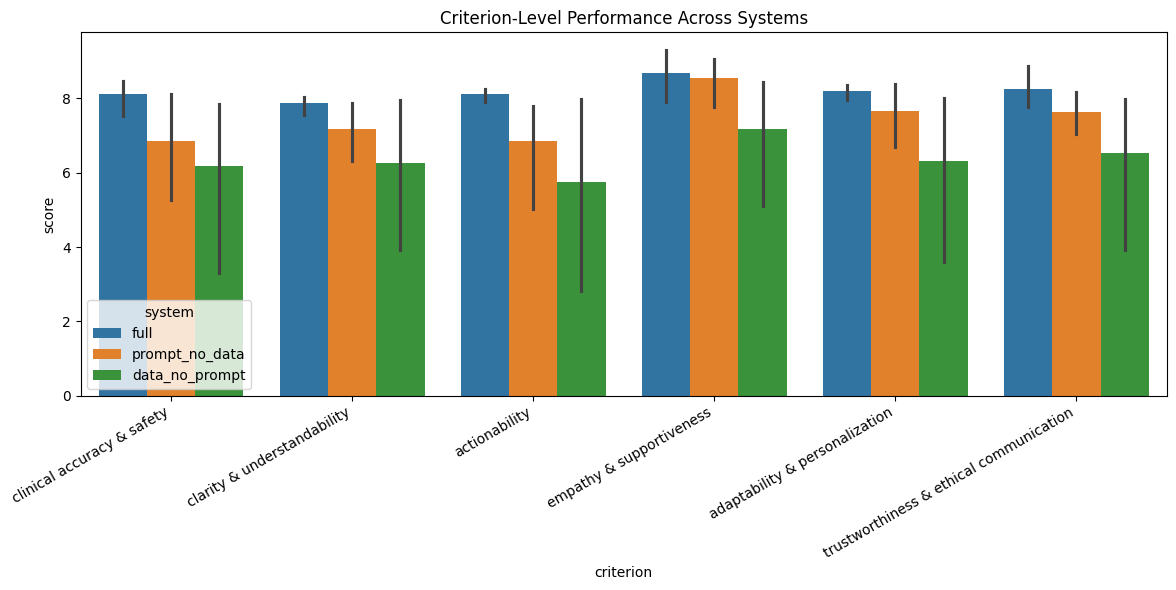

In [28]:
# Combine all summaries into one dataframe
df_gpt_summary["evaluator"] = "GPT"
df_llama_summary["evaluator"] = "LLaMA"
df_qwen_summary["evaluator"] = "Qwen"

df_all_criteria = pd.concat([
    df_gpt_summary,
    df_llama_summary,
    df_qwen_summary
])

# Melt for plotting
df_melt = df_all_criteria.melt(
    id_vars=["criterion", "evaluator"],
    value_vars=["full", "prompt_no_data", "data_no_prompt"],
    var_name="system",
    value_name="score"
)

plt.figure(figsize=(12,6))
sns.barplot(data=df_melt, x="criterion", y="score", hue="system")
plt.xticks(rotation=30, ha="right")
plt.title("Criterion-Level Performance Across Systems")
plt.tight_layout()

plt.savefig("criterion_performance.png", dpi=300)
plt.show()

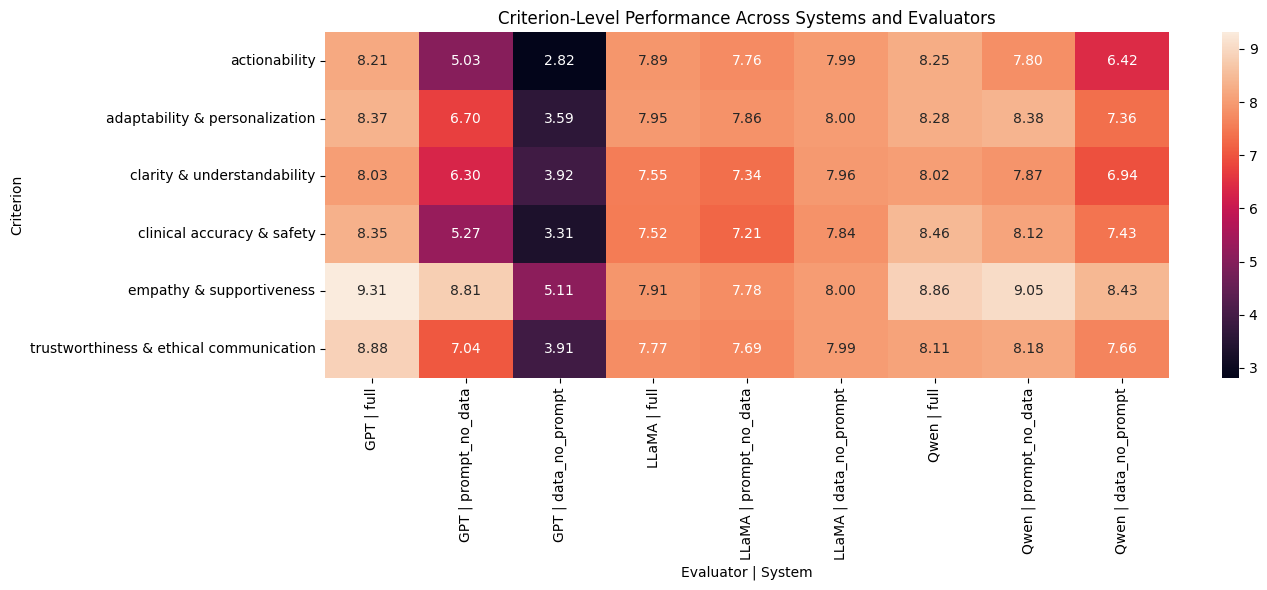

In [29]:
# Create combined column for pivot
df_melt_copy = df_melt.copy()
df_melt_copy["row"] = df_melt_copy["evaluator"] + " | " + df_melt_copy["system"]

pivot_alt = df_melt_copy.pivot(
    index="criterion",
    columns="row",
    values="score"
)

# Optional: reorder columns
order = [
    "GPT | full", "GPT | prompt_no_data", "GPT | data_no_prompt",
    "LLaMA | full", "LLaMA | prompt_no_data", "LLaMA | data_no_prompt",
    "Qwen | full", "Qwen | prompt_no_data", "Qwen | data_no_prompt"
]

pivot_alt = pivot_alt[order]

plt.figure(figsize=(14,6))
sns.heatmap(pivot_alt, annot=True, fmt=".2f")

plt.title("Criterion-Level Performance Across Systems and Evaluators")
plt.ylabel("Criterion")
plt.xlabel("Evaluator | System")

plt.tight_layout()
plt.savefig("combined_heatmap_alt.png", dpi=300)
plt.show()

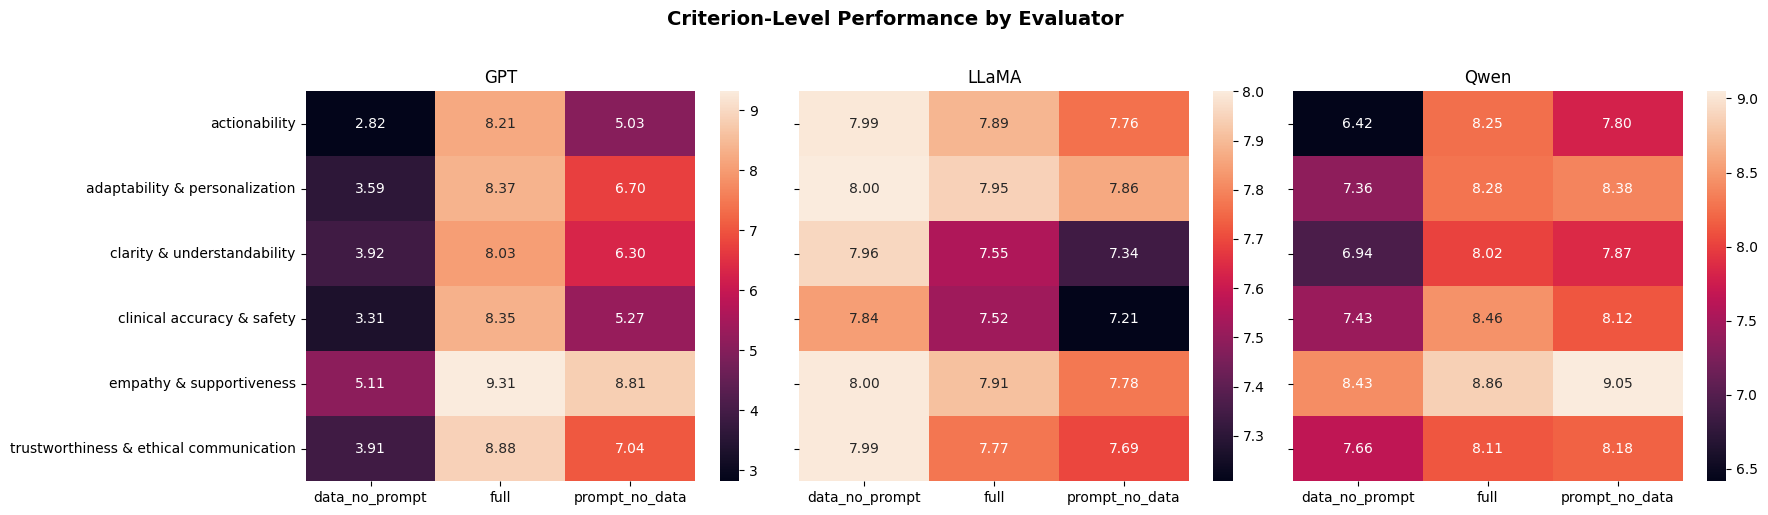

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18,5), sharey=True)

for ax, evaluator in zip(axes, ["GPT", "LLaMA", "Qwen"]):
    sub = df_melt[df_melt["evaluator"] == evaluator]
    
    pivot = sub.pivot(
        index="criterion",
        columns="system",
        values="score"
    )
    
    sns.heatmap(pivot, annot=True, fmt=".2f", ax=ax)
    ax.set_title(evaluator)
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.suptitle("Criterion-Level Performance by Evaluator", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("facet_heatmaps.png", dpi=300)
plt.show()

## Cohen's d

In [31]:
def cohens_d(x, y):
    return (x.mean() - y.mean()) / np.sqrt((x.var() + y.var()) / 2)

In [32]:
def cohens_d(x, y):
    """Calculate Cohen's d effect size between two groups."""
    return (x.mean() - y.mean()) / np.sqrt((x.var() + y.var()) / 2)

# Compute effect sizes for each evaluator across all criteria
print("="*70)
print("Effect Sizes (Cohen's d) - Criteria Ratings")
print("="*70)

for evaluator_name, df_crit in [("GPT", df_gpt_criteria), ("Llama", df_llama_criteria), ("Qwen", df_qwen_criteria)]:
    print(f"\n{evaluator_name}:")
    print(f"  Full vs Prompt No Data: {cohens_d(df_crit.filter(regex='_rating_full').mean(axis=1), df_crit.filter(regex='_rating_prompt_no_data').mean(axis=1)):.3f}")
    print(f"  Full vs Data No Prompt: {cohens_d(df_crit.filter(regex='_rating_full').mean(axis=1), df_crit.filter(regex='_rating_data_no_prompt').mean(axis=1)):.3f}")
    print(f"  Prompt No Data vs Data No Prompt: {cohens_d(df_crit.filter(regex='_rating_prompt_no_data').mean(axis=1), df_crit.filter(regex='_rating_data_no_prompt').mean(axis=1)):.3f}")

Effect Sizes (Cohen's d) - Criteria Ratings

GPT:
  Full vs Prompt No Data: 2.231
  Full vs Data No Prompt: 7.236
  Prompt No Data vs Data No Prompt: 2.600

Llama:
  Full vs Prompt No Data: 0.256
  Full vs Data No Prompt: -0.552
  Prompt No Data vs Data No Prompt: -0.678

Qwen:
  Full vs Prompt No Data: 0.306
  Full vs Data No Prompt: 1.427
  Prompt No Data vs Data No Prompt: 1.236


In [33]:
# Rank criteria by Full vs Data gap (GPT example)

df_gpt_summary["full_minus_data"] = (
    df_gpt_summary["full"] - df_gpt_summary["data_no_prompt"]
)

df_gpt_summary.sort_values("full_minus_data", ascending=False)

,criterion,full,prompt_no_data,data_no_prompt,evaluator,full_minus_data
2,actionability,8.212,5.032,2.816,GPT,5.396
0,clinical accuracy & safety,8.346,5.268,3.310,GPT,5.036
5,trustworthiness & ethical communication,8.880,7.038,3.914,GPT,4.966
4,adaptability & personalization,8.368,6.704,3.586,GPT,4.782
3,empathy & supportiveness,9.312,8.810,5.112,GPT,4.200
1,clarity & understandability,8.032,6.304,3.922,GPT,4.110


In [34]:
# Combine all evaluators
df_all_criteria = pd.concat([
    df_gpt_summary.assign(evaluator="GPT"),
    df_llama_summary.assign(evaluator="LLaMA"),
    df_qwen_summary.assign(evaluator="Qwen")
])

# Average gap across evaluators
df_avg = df_all_criteria.groupby("criterion")["full_minus_data"].mean().sort_values(ascending=False)

print(df_avg)

criterion
actionability                              5.396
clinical accuracy & safety                 5.036
trustworthiness & ethical communication    4.966
adaptability & personalization             4.782
empathy & supportiveness                   4.200
clarity & understandability                4.110
Name: full_minus_data, dtype: float64


In [35]:
# Combine all evaluator summaries
df_all = pd.concat([
    df_gpt_summary.assign(evaluator="GPT"),
    df_llama_summary.assign(evaluator="LLaMA"),
    df_qwen_summary.assign(evaluator="Qwen")
])

# Clean formatting (optional but nice)
df_all = df_all[[
    "evaluator", "criterion",
    "full", "prompt_no_data", "data_no_prompt"
]]

df_all = df_all.sort_values(["criterion", "evaluator"]).reset_index(drop=True)

df_all.head(10)


,evaluator,criterion,full,prompt_no_data,data_no_prompt
0,GPT,actionability,8.212000,5.032,2.816
1,LLaMA,actionability,7.891176,7.764,7.992
2,Qwen,actionability,8.252000,7.800,6.418
3,GPT,adaptability & personalization,8.368000,6.704,3.586
4,LLaMA,adaptability & personalization,7.947059,7.864,8.000
5,Qwen,adaptability & personalization,8.280000,8.376,7.358
6,GPT,clarity & understandability,8.032000,6.304,3.922
7,LLaMA,clarity & understandability,7.550000,7.344,7.958
8,Qwen,clarity & understandability,8.018000,7.866,6.940
9,GPT,clinical accuracy & safety,8.346000,5.268,3.310
